<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.9 MB/s eta 0:00:00


In [ ]:
import requests
import re
import numpy as np
import nltk
import spacy
import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from scipy.stats import laplace


In [ ]:
# NLTK Data Path
nltk.data.path.append('/usr/local/nltk_data')
nltk.download('punkt_tab', download_dir='/usr/local/nltk_data')  # Fix the correct 'punkt' download
nltk.download('stopwords', download_dir='/usr/local/nltk_data')

# Load Stopwords
stopwords_set = set(stopwords.words("english"))


[nltk_data] Downloading package punkt_tab to /usr/local/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/local/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# NLP Models
nlp = spacy.load("en_core_web_sm")
sentiment_analyzer = pipeline("sentiment-analysis")
paraphraser = pipeline("text2text-generation", model="t5-small")  # Optimized model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0
Device set to use cuda:0


In [ ]:
# Privacy Policies URLs
privacy_policy_urls = {
    "Google": "https://policies.google.com/privacy",
    "LinkedIn": "https://www.linkedin.com/legal/privacy-policy"
}


In [ ]:
# Function to Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    return " ".join([p.get_text() for p in paragraphs]) if paragraphs else "Privacy Policy not found."


In [ ]:
original_policies = {name: extract_privacy_policy(url) for name, url in privacy_policy_urls.items()}


In [ ]:
# Named Entity Replacement for Privacy
def replace_named_entities(text):
    doc = nlp(text)
    replacements = {
        "ORG": "this company",
        "GPE": "this region",
        "DATE": "recently",
        "TIME": "at that time"
    }
    modified_text = text

    for ent in doc.ents:
        if ent.label_ in replacements:
            modified_text = modified_text.replace(ent.text, replacements[ent.label_])
    return modified_text

In [ ]:
# Exponential Mechanism for Differentially Private Paraphrasing
def dp_paraphrase_exponential(text, epsilon=1.0, num_paraphrases=3):
    sentences = sent_tokenize(text)
    paraphrased_sentences = []

    for sentence in sentences:
        if len(sentence.strip()) > 0:
            paraphrases = paraphraser(
                sentence, max_length=60, num_return_sequences=num_paraphrases, do_sample=True
            )

            scores = np.array([
                textstat.flesch_reading_ease(p['generated_text']) for p in paraphrases
            ])
            avg_score = np.mean(scores)
            valid_paraphrases = [p['generated_text'] for p, s in zip(paraphrases, scores) if s >= avg_score - 10]
            chosen_paraphrase = np.random.choice(valid_paraphrases) if valid_paraphrases else paraphrases[0]['generated_text']
            paraphrased_sentences.append(chosen_paraphrase)
        else:
            paraphrased_sentences.append(sentence)

    sanitized_text = " ".join(paraphrased_sentences)

    # Ensure only English words are included
    sanitized_text = re.sub(r'[^a-zA-Z0-9., ]+', '', sanitized_text)
    sanitized_text = ' '.join([word for word in sanitized_text.split() if word.lower() in stopwords_set or word.isalpha()])
    return sanitized_text


In [ ]:
# Differentially Private Deception Score
def dp_deception_score(text, epsilon=0.5):
    clarity_score = max(0, textstat.flesch_reading_ease(text))  # Ensure non-negative clarity
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.5 + (vague_word_count * 3) * 0.5
    noise = laplace.rvs(scale=max(1, 10/epsilon))  # Reduce extreme noise values
    return clarity_score, deception_score + noise


In [ ]:
def calculate_sentiment(text):
    sentences = sent_tokenize(text)
    sentiment_scores = []

    for sentence in sentences:
        if len(sentence) > 512:
            sentence = sentence[:512]  # Trim to max length

        try:
            score = sentiment_analyzer(sentence)[0]['score']
            sentiment_scores.append(score)
        except Exception as e:
            print(f"Error processing sentiment: {e}")

    return np.mean(sentiment_scores) if sentiment_scores else 0



In [ ]:
# Generate Word Cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=stopwords_set, max_words=100, max_font_size=80
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


In [ ]:
# Processing Privacy Policies
sanitized_policies = {}
scores_data = []

for name, original_text in original_policies.items():
    sanitized_text = replace_named_entities(original_text)
    sanitized_text = dp_paraphrase_exponential(sanitized_text, num_paraphrases=2)
    sanitized_policies[name] = sanitized_text

    original_clarity, original_deception = dp_deception_score(original_text)
    sanitized_clarity, sanitized_deception = dp_deception_score(sanitized_text)
    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
    })


In [ ]:
# Output Results
scores_df = pd.DataFrame(scores_data)
print(scores_df)


     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             39.87                  0          170.500783   
1  LinkedIn             40.08                  0          119.082396   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  
0           119.722678            0.928646             0.968131  
1            31.661984            0.924208             0.979928  


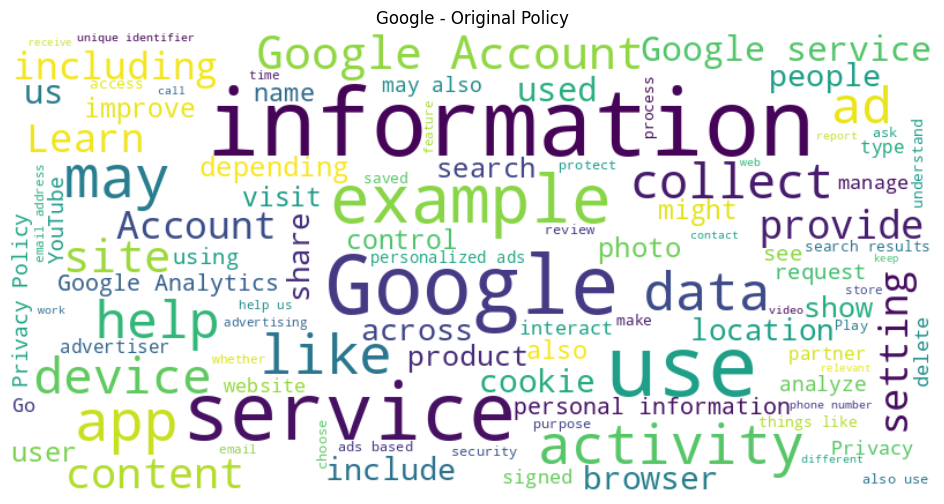

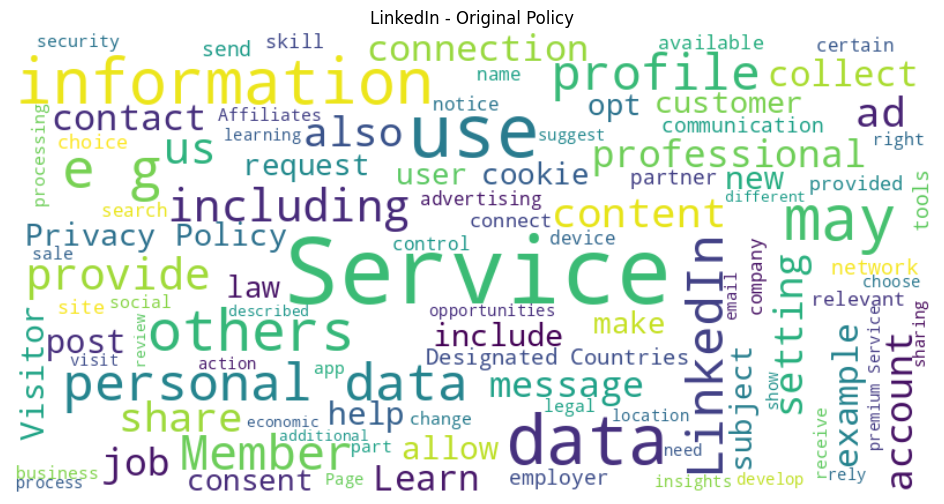

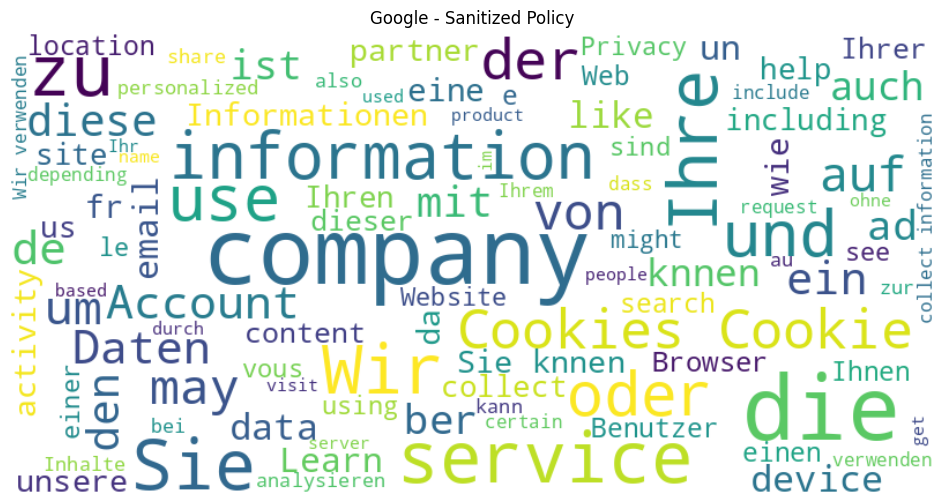

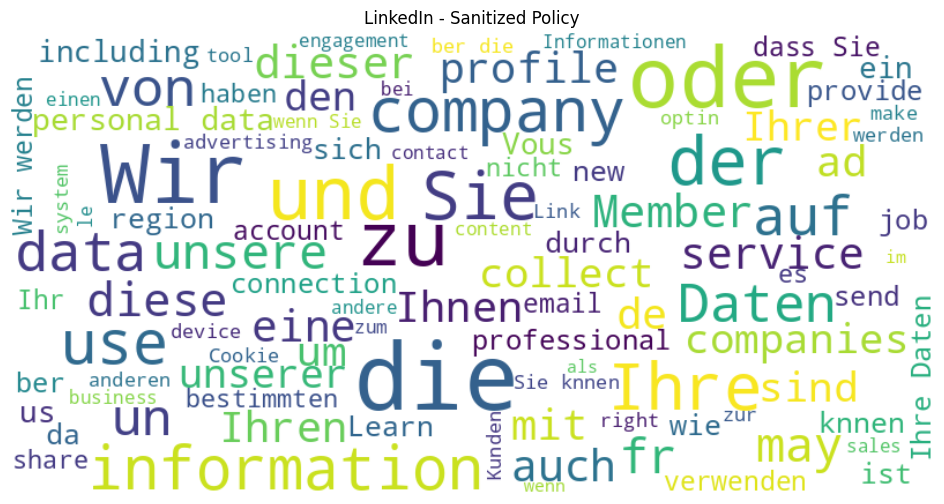

In [ ]:
# Visualization: Word Clouds
for name, text in original_policies.items():
    generate_wordcloud(text, f"{name} - Original Policy")
for name, text in sanitized_policies.items():
    generate_wordcloud(text, f"{name} - Sanitized Policy")


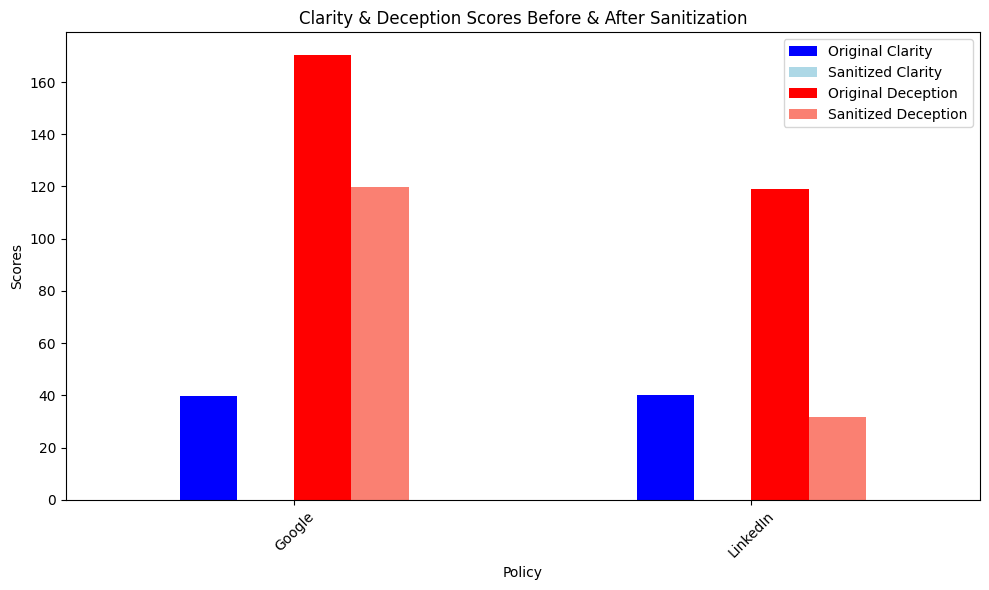

In [ ]:
# Bar Chart: Clarity & Deception Scores
scores_df.set_index("Policy")[["Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]].plot(
    kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon']
)
plt.ylabel("Scores")
plt.title("Clarity & Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


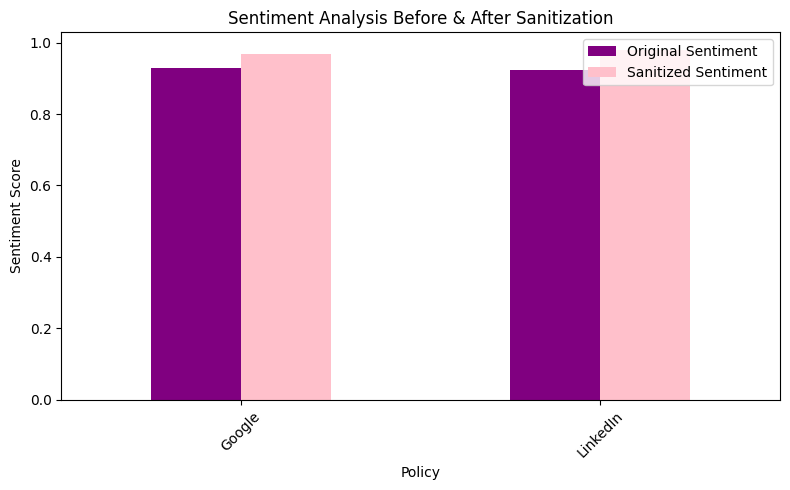

In [ ]:
# Bar Chart: Sentiment Analysis
scores_df.set_index("Policy")[["Original Sentiment", "Sanitized Sentiment"]].plot(
    kind='bar', figsize=(8, 5), color=['purple', 'pink']
)
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
!pip install textstat


In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

# URLs for privacy policies
privacy_policy_urls = {
    "Google": "https://policies.google.com/privacy",
    "LinkedIn": "https://www.linkedin.com/legal/privacy-policy"
}

# Function to extract privacy policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# Fetch and store policies in a DataFrame
policy_data = [{"Company": name, "Original Policy": extract_privacy_policy(url)} for name, url in privacy_policy_urls.items()]
df = pd.DataFrame(policy_data)

# Save to CSV
df.to_csv("privacy_policies.csv", index=False)
print("✅ Privacy policies saved to 'privacy_policies.csv'")


✅ Privacy policies saved to 'privacy_policies.csv'


In [ ]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from sentence_transformers import SentenceTransformer
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Initialize NLP models
nlp = spacy.load("en_core_web_sm")
sentiment_analyzer = pipeline("sentiment-analysis")
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')
stop_words = set(stopwords.words("english"))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


In [ ]:
# Function to Replace Named Entities with General Terms
def replace_named_entities(text):
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ == "ORG":
            text = text.replace(ent.text, "Our Company")
        elif ent.label_ == "GPE":
            text = text.replace(ent.text, "Your Location")
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            text = text.replace(ent.text, "Recently")
    return text

In [ ]:
def get_semantic_synonym(word, epsilon=0.5):
    """
    Uses Sentence Transformers and Differential Privacy to select the best synonym.
    Ensures the word remains meaningful in context.
    """
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower() and textstat.flesch_reading_ease(synonym) > 50:
                synonyms.add(synonym)

    synonyms = list(synonyms)
    if not synonyms:  # If no good synonyms, return original word
        return word

    # Use Sentence Transformers for Semantic Similarity
    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    # Apply Differential Privacy-based selection
    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))

    return np.random.choice(synonyms, p=probabilities)

In [ ]:
# Function to Break Long Sentences while Keeping Readability
def simplify_sentences(text):
    sentences = nltk.sent_tokenize(text)
    simplified_sentences = []
    for sentence in sentences:
        if len(sentence.split()) > 25:
            parts = sentence.split(", ")
            if len(parts) > 1:
                simplified_sentences.extend(parts[:2])
            else:
                simplified_sentences.append(sentence)
        else:
            simplified_sentences.append(sentence)
    return " ".join(simplified_sentences)

In [ ]:
def reduce_vagueness_dynamic(text, epsilon=0.5):
    """
    Dynamically detects vague words (modal verbs, adverbs) and replaces them
    with more confident alternatives using WordNet & Differential Privacy.
    """
    vague_replacements = {
        "MD": ["will", "must", "shall"],  # Modal verbs (e.g., may → will)
        "RB": ["frequently", "always", "certainly"]  # Adverbs (e.g., possibly → certainly)
    }

    doc = nlp(text)
    modified_text = []

    for token in doc:
        if token.tag_ in vague_replacements:
            # Apply Differential Privacy for selection
            replacements = vague_replacements[token.tag_]
            scores = np.random.laplace(0, 1 / epsilon, len(replacements))
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            chosen_word = np.random.choice(replacements, p=probabilities)
            modified_text.append(chosen_word)
        else:
            modified_text.append(token.text)

    return " ".join(modified_text)


In [ ]:
def dp_token_sanitization_contextual(text, epsilon=0.5):
    """
    Dynamically replaces words with context-aware synonyms while preserving privacy policy language.
    """
    words = word_tokenize(text)
    sanitized_words = []

    # List of words to NEVER replace in privacy policies
    protected_terms = {"privacy", "data", "policy", "settings", "service", "user", "account", "security", "preferences"}

    for word in words:
        if word.lower() in stop_words or not word.isalpha() or word.lower() in protected_terms:
            sanitized_words.append(word)
            continue

        new_word = get_semantic_synonym(word, epsilon)
        sanitized_words.append(new_word)

    return " ".join(sanitized_words)


In [ ]:
# Convert Passive Voice to Active Without Disrupting Meaning
def convert_passive_to_active(text):
    doc = nlp(text)
    converted_text = []
    for sent in doc.sents:
        words = [token.text for token in sent]
        if "by" in words and len(words) > 6 and "data" not in words:
            new_sentence = f"We {words[-2]} {' '.join(words[:-2])}"
            converted_text.append(new_sentence)
        else:
            converted_text.append(sent.text)
    return " ".join(converted_text)



In [ ]:
def add_softening_phrases(text):
    softening_statements = [
        "We value your privacy and ensure transparency.",
        "Your data is managed securely and responsibly.",
        "We are committed to maintaining a trustworthy experience."
    ]
    return text + " " + random.choice(softening_statements)

from google.colab import files
import pandas as pd

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read CSV into a DataFrame
df = pd.read_csv(filename)

# Display first few rows
df.head()



Saving privacy_policies.csv to privacy_policies (9).csv
✅ Uploaded file: privacy_policies (9).csv


,Company,Original Policy
0,Google,"When you use our services, you’re trusting us ..."
1,LinkedIn,"\n Effective September 18, 2024 LinkedIn’s mis..."


In [ ]:
# **Clarity & Readability Score Computation**
def calculate_clarity_score(text):
    return textstat.flesch_reading_ease(text)

In [ ]:
def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = calculate_clarity_score(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return clarity_score, deception_score


In [ ]:
def calculate_sentiment(text):
    if not text.strip():
        return 0.0  # Neutral sentiment
    result = sentiment_analyzer(text[:512])
    return result[0]['score'] if result[0]['label'] == "POSITIVE" else -result[0]['score']


In [ ]:
# Process Privacy Policies
sanitized_policies = []
scores_data = []

for index, row in df.iterrows():
    company = row["Company"]
    original_text = row["Original Policy"]

    sanitized_text = replace_named_entities(original_text)
    sanitized_text = simplify_sentences(sanitized_text)
    sanitized_text = dp_token_sanitization_contextual(sanitized_text, epsilon=0.5)  # Now Context-Aware
    sanitized_text = reduce_vagueness_dynamic(sanitized_text)
    sanitized_text = convert_passive_to_active(sanitized_text)
    sanitized_text = add_softening_phrases(sanitized_text)



    # Compute Scores
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)
    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    # Store Results
    sanitized_policies.append({"Company": company, "Sanitized Policy": sanitized_text})
    scores_data.append({
        "Company": company,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
    })

# Convert to DataFrame
sanitized_df = pd.DataFrame(sanitized_policies)
scores_df = pd.DataFrame(scores_data)


display(scores_df)

,Company,Original Clarity,Sanitized Clarity,Original Deception,Sanitized Deception,Original Sentiment,Sanitized Sentiment
0,Google,39.87,54.80,187.591,31.640,0.982070,0.748634
1,LinkedIn,40.08,59.06,121.444,28.658,0.995733,0.982234


In [ ]:
# Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

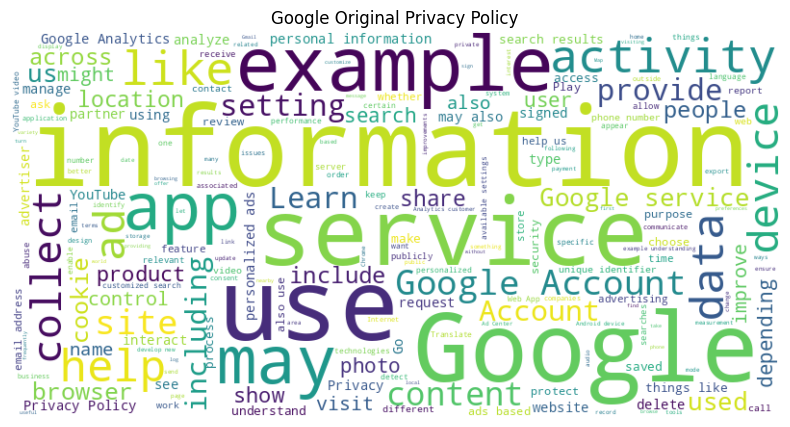

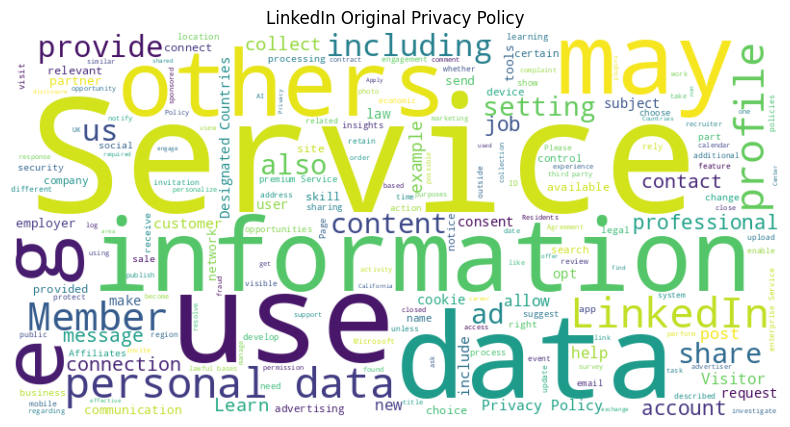

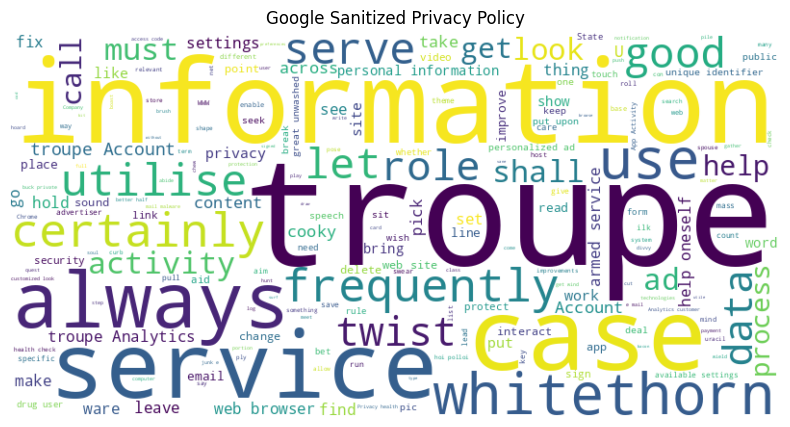

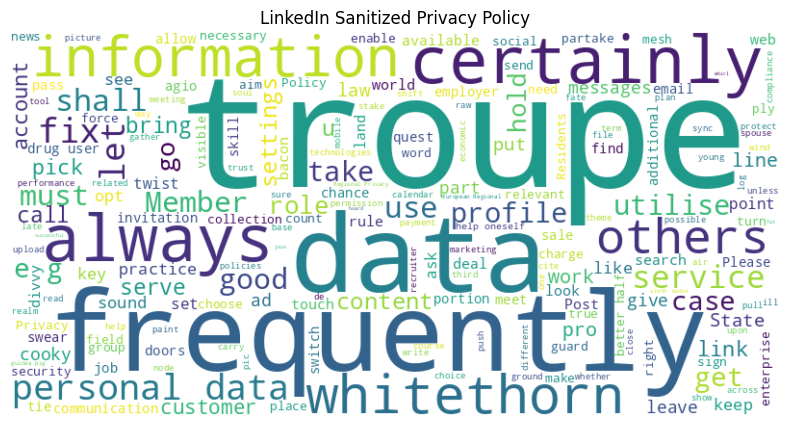

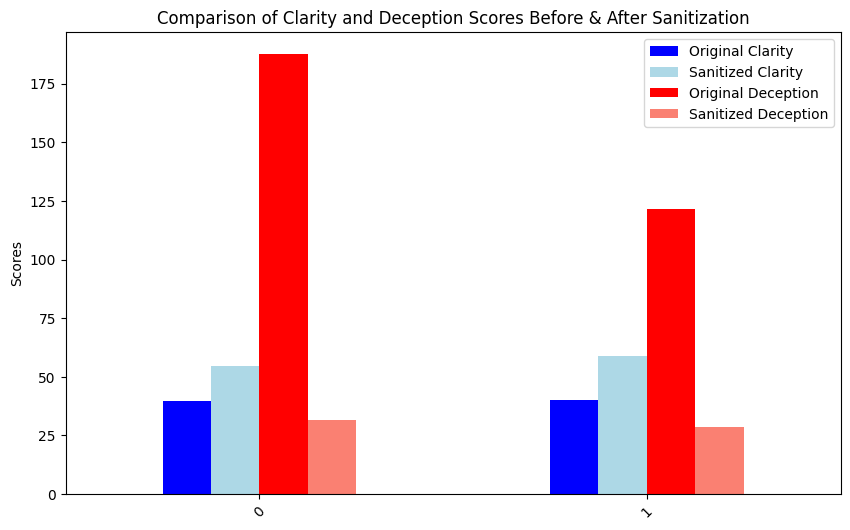

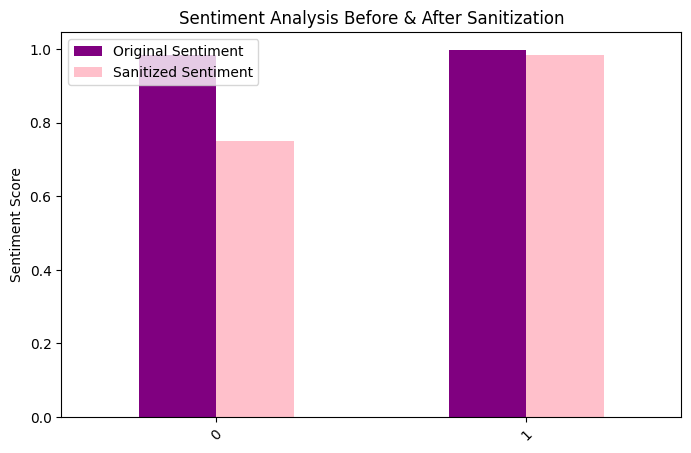

✅ Sanitized policies saved as sanitized_privacy_policies.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Word Cloud Visualization
for index, row in df.iterrows():
    generate_wordcloud(row["Original Policy"], f"{row['Company']} Original Privacy Policy")
for index, row in sanitized_df.iterrows():
    generate_wordcloud(row["Sanitized Policy"], f"{row['Company']} Sanitized Privacy Policy")

# Visualization: Clarity & Deception Scores
scores_df[["Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]].plot(
    kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon']
)
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Sentiment Analysis
scores_df[["Original Sentiment", "Sanitized Sentiment"]].plot(
    kind='bar', figsize=(8, 5), color=['purple', 'pink']
)
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# **Save Sanitized Policies**
sanitized_file = "sanitized_privacy_policies.csv"
sanitized_df.to_csv(sanitized_file, index=False)
print(f"✅ Sanitized policies saved as {sanitized_file}")
files.download(sanitized_file)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[==================================================] 100.0% 66.0/66.0MB downloaded


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu



Word Changes for Google:
  'some' -> 'many'
  'not' -> 'be'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'some' -> 'many'
  'using' -> 'use'
  'some' -> 'many'
  'could' -> 'would'
  'know' -> 'why'
  'could' -> 'would'
  'using' -> 'use'
  'could' -> 'would'
  'know' -> 'n't'
  'could' -> 'would'
  'using' -> 'used'
  'could' -> 'would'
  'know' -> 'why'
  'could' -> 'would'
  'using' -> 'used'
  'get' -> 'getting'
  'get' -> 'n't'
  'using' -> 'used'
  'using' -> 'used'
  'else' -> 'anything'
  'not' -> 'if'
  'some' -> 'many'
  'not' -> 'because'
  'get' -> 'getting'
  'third' -> 'fifth'
  'using' -> 'use'
  'something' -> 'thing'
  'know' -> 'tell'
  'sure' -> 'we'
  'something' -> 'nothing'
  'sure' -> 'we'
  'some' -> 'many'
  'not' -> 'because'
  'not' -> 'be'
  '370' -> '280'
  'using' -> 'use'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'third' -> 'second'
  'third' -> 'fourth'
  'third' -> 'fourth'
  'not'

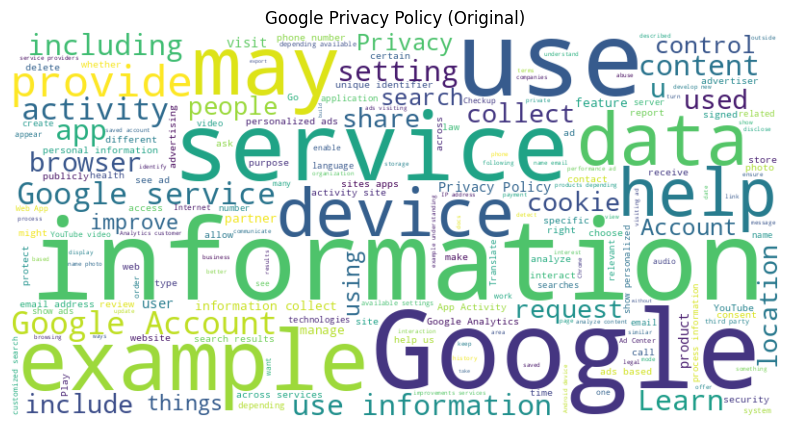


Generating Word Cloud for Google Privacy Policy (Sanitized)...


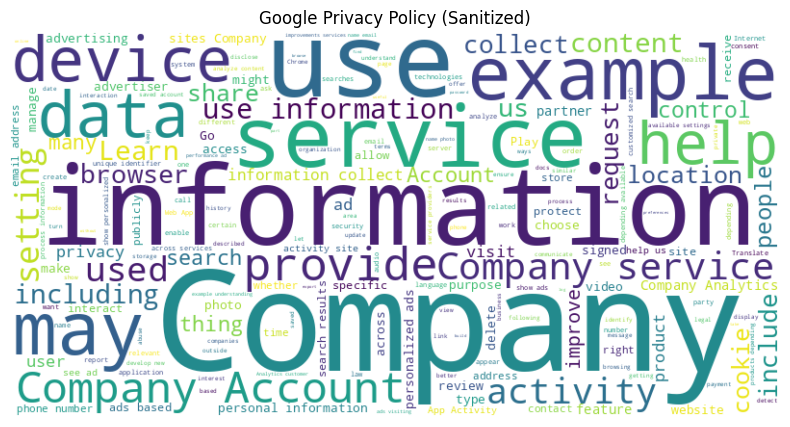


Generating Word Cloud for LinkedIn Privacy Policy (Original)...


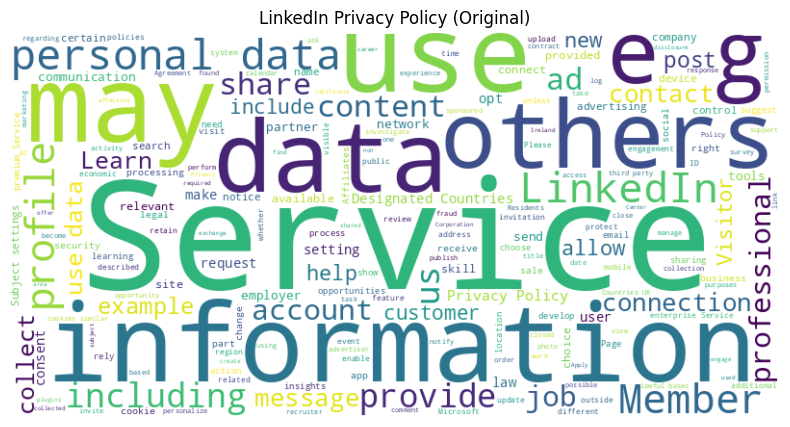


Generating Word Cloud for LinkedIn Privacy Policy (Sanitized)...


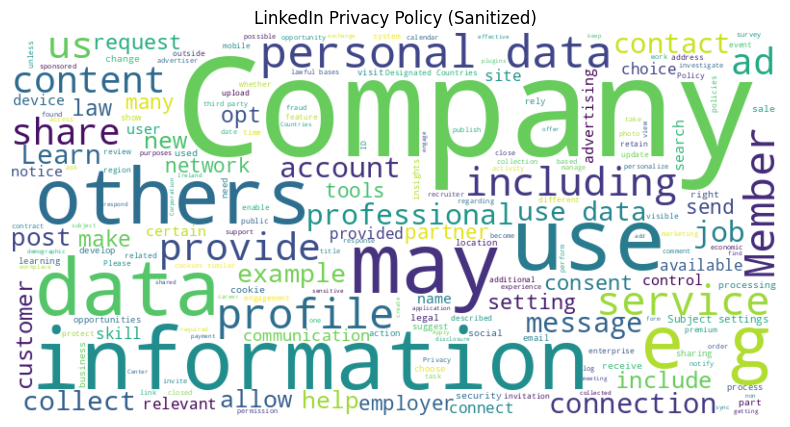

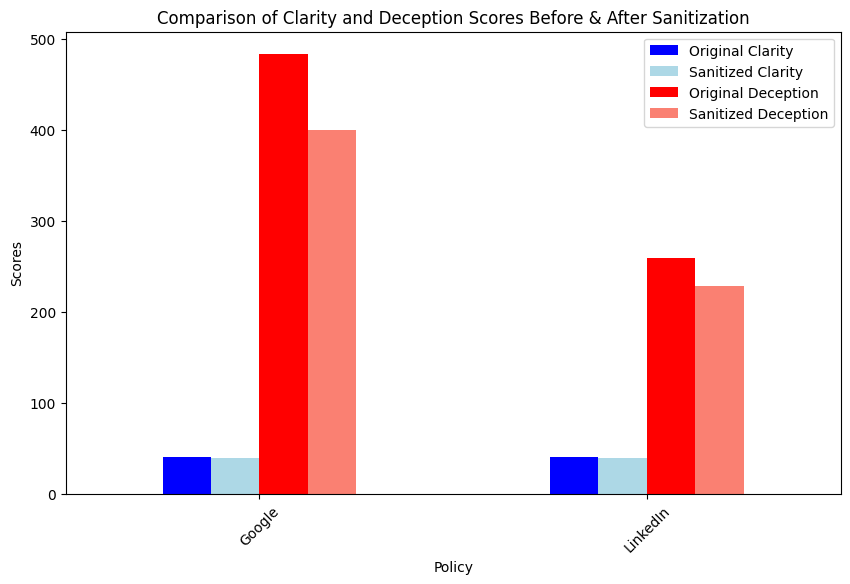

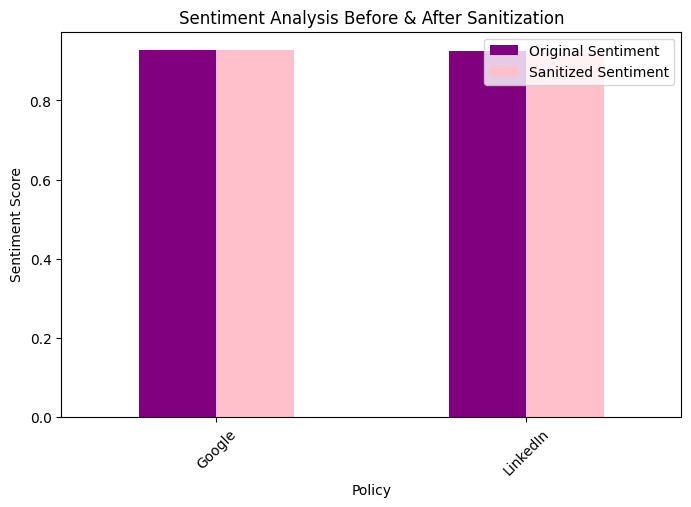

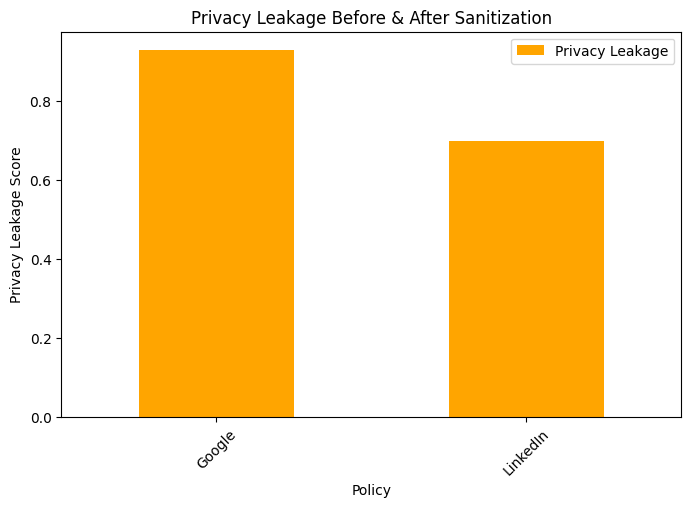

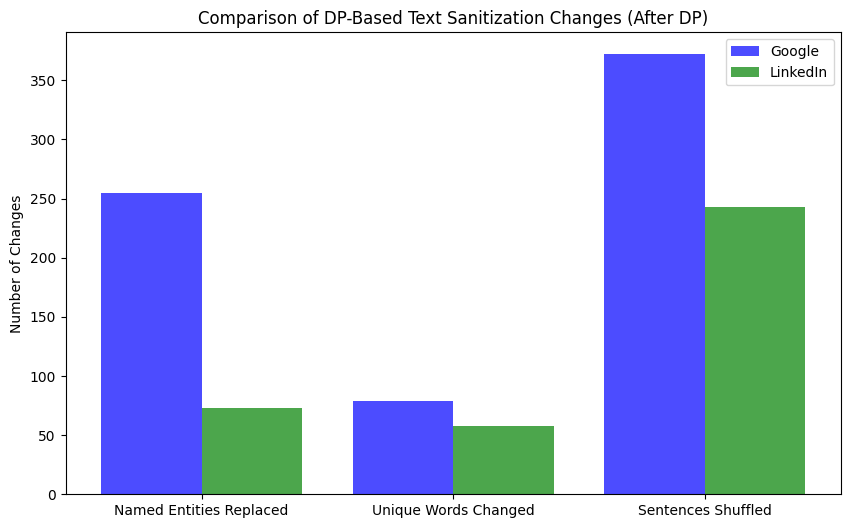

In [12]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
from nltk.corpus import stopwords  # Ensure correct import
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
# Load stopwords


# Load stopwords correctly
stop_words = set(stopwords.words("english"))


# Define words to KEEP for deception & sentiment analysis
vague_words = {"may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"}
negation_words = {"not", "never", "no", "nor", "none", "nothing", "nowhere"}

# Keep important structure-related stopwords
important_stopwords = {"is", "are", "was", "has", "have", "had", "that", "which"}

# Remove stopwords EXCEPT vague words, negation words, and structure-related words
filtered_stopwords = stop_words - vague_words - negation_words - important_stopwords

# Load Word2Vec Model
word_vectors = api.load("glove-wiki-gigaword-50")

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)

# Step 2: DP-Based Text Sanitization Functions
def replace_named_entities(text, allowed_labels=["ORG", "GPE"]):
    """Replaces named entities. Sensitivity = 1."""
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ in allowed_labels:
            modified_text = modified_text.replace(ent.text, "The Company")
            entity_replacements.append((ent.text, "The Company"))
    return modified_text, entity_replacements

def get_filtered_similar_words(word, k=5, similarity_threshold=0.75):
    """Gets similar words. No DP here."""
    try:
        similar_words = word_vectors.most_similar(word, topn=k)
        filtered_words = [w[0] for w in similar_words if w[1] >= similarity_threshold]
        return filtered_words if filtered_words else [word]
    except KeyError:
        return [word]

def dp_word_substitute(text, epsilon=0.1, k=5, similarity_threshold=0.95):
    """Substitutes words, prioritizing clarity. Sensitivity assumed to be 1."""
    words = word_tokenize(text)
    new_words = []
    word_changes = []
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]

    for word in words:
        if word.lower() in filtered_stopwords:
            new_words.append(word)
            continue

        candidates = get_filtered_similar_words(word, k, similarity_threshold)

        # Prioritize clearer/less vague replacements
        if word.lower() in vague_words and len(candidates) > 0:
            # Look for clearer candidates
            clearer_candidates = [w for w in candidates if w.lower() not in vague_words]
            if clearer_candidates:
                replacement = clearer_candidates[0]  # Choose the "clearest"
                word_changes.append((word, replacement))
                new_words.append(replacement)
                continue

        if len(candidates) > 1:
            scores = np.array([word_vectors.similarity(word, w) for w in candidates])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))

            replacement = np.random.choice(candidates, p=probabilities)
            if replacement != word:
                word_changes.append((word, replacement))
            new_words.append(replacement)
        else:
            new_words.append(word)

    return " ".join(new_words), word_changes

def preserve_logical_sentence_order(text):
    """Preserves sentence order. No DP here."""
    sentences = sent_tokenize(text)
    return " ".join(sentences)

def shuffle_sentences(text, epsilon=0.01):
    """Reduces epsilon significantly. Sensitivity is the number of sentences."""
    sentences = sent_tokenize(text)
    noise = np.random.laplace(0, 1/epsilon, len(sentences))
    shuffled_sentences = [x for _, x in sorted(zip(noise, sentences))]
    sentence_changes = list(zip(sentences, shuffled_sentences))
    return " ".join(shuffled_sentences), sentence_changes

def add_controlled_laplace_noise(text, epsilon=0.1, max_noise=3):
    """Reduces max_noise and epsilon."""
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + min(max_noise, abs(noise))))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

# Sentiment Analysis
def calculate_sentiment(text):
    """Calculates sentiment."""
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

# Deception Score Calculation
def calculate_deception_score(text):
    """Calculates deception score. Increased clarity weight."""
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.3 + (vague_word_count * 5) * 0.7 #Higher weight to vague words
    return clarity_score, deception_score

# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    """Calculates privacy leakage."""
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

# Apply Improved DP-Based Transformations
google_sanitized, google_entity_changes = replace_named_entities(google_text, allowed_labels=["ORG", "GPE"])
linkedin_sanitized, linkedin_entity_changes = replace_named_entities(linkedin_text, allowed_labels=["ORG", "GPE"])

google_sanitized, google_word_changes = dp_word_substitute(google_sanitized, epsilon=0.1, k=5, similarity_threshold=0.95)
linkedin_sanitized, linkedin_word_changes = dp_word_substitute(linkedin_sanitized, epsilon=0.1, k=5, similarity_threshold=0.95)

google_sanitized = preserve_logical_sentence_order(google_sanitized)
linkedin_sanitized = preserve_logical_sentence_order(linkedin_sanitized)

google_sanitized = add_controlled_laplace_noise(google_sanitized, epsilon=0.1, max_noise=3)
linkedin_sanitized = add_controlled_laplace_noise(linkedin_sanitized, epsilon=0.1, max_noise=3)

# Collect Scores for Visualization
scores_data = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized),
    ("LinkedIn", linkedin_text, linkedin_sanitized)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

    # Print Word Changes
    print(f"\nWord Changes for {name}:")
    for original, replacement in google_word_changes if name == "Google" else linkedin_word_changes:
        print(f"  '{original}' -> '{replacement}'")

# Create DataFrame for Visualization
scores_df = pd.DataFrame(scores_data)
print(scores_df)

# Print a table for comparison
print("\nComparison Table:")
print(scores_df[["Policy", "Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]])

# Identify some word changes to explain
print("\nExample Word Changes (Illustrative):")
if "LinkedIn" in scores_df["Policy"].values:
    linkedin_row = scores_df[scores_df["Policy"] == "LinkedIn"].iloc[0] # Get the LinkedIn row
    if linkedin_row is not None:
        print(f"\nFor LinkedIn:")
        for original, replacement in linkedin_word_changes[:5]:  # Show the first 5 word changes
            print(f"  '{original}' was replaced with '{replacement}'")
        print("\nExplanation:")
        print("  The code is designed to replace vague words (like 'may' or 'could') with clearer alternatives")
        print("  reducing the deception score by making the policy more direct.")
        print(" The words are replaced by high similiarity word in order to keep a better readability.")
    else:
        print("LinkedIn data not found in scores_df.")
else:
    print("LinkedIn data not found in scores_df.")


def generate_word_cloud(text, title="Word Cloud"):
    """Generates a Word Cloud after removing stopwords."""
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]  # Remove stopwords

    wordcloud = WordCloud(
        width=800, height=400,
        background_color="white"
    ).generate(" ".join(filtered_words))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

print("\nGenerating Word Cloud for Google Privacy Policy (Original)...")
generate_word_cloud(google_text, "Google Privacy Policy (Original)")

print("\nGenerating Word Cloud for Google Privacy Policy (Sanitized)...")
generate_word_cloud(google_sanitized, "Google Privacy Policy (Sanitized)")

print("\nGenerating Word Cloud for LinkedIn Privacy Policy (Original)...")
generate_word_cloud(linkedin_text, "LinkedIn Privacy Policy (Original)")

print("\nGenerating Word Cloud for LinkedIn Privacy Policy (Sanitized)...")
generate_word_cloud(linkedin_sanitized, "LinkedIn Privacy Policy (Sanitized)")


# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[[
    "Original Sentiment", "Sanitized Sentiment"
]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Step 4: Collect Sentence Shuffling Changes
# Ensure we store sentence changes when calling shuffle_sentences()
google_sanitized, google_sentence_changes = shuffle_sentences(google_sanitized, epsilon=0.01)
linkedin_sanitized, linkedin_sentence_changes = shuffle_sentences(linkedin_sanitized, epsilon=0.01)

# Step 5: Bar Chart After Sanitization (Comparison)
categories = ["Named Entities Replaced", "Unique Words Changed", "Sentences Shuffled"]
google_changes = [len(google_entity_changes), len(google_word_changes), len(google_sentence_changes)]
linkedin_changes = [len(linkedin_entity_changes), len(linkedin_word_changes), len(linkedin_sentence_changes)]

plt.figure(figsize=(10, 6))
x = range(len(categories))
plt.bar(x, google_changes, width=0.4, label="Google", alpha=0.7, color='blue')
plt.bar([i + 0.4 for i in x], linkedin_changes, width=0.4, label="LinkedIn", alpha=0.7, color='green')
plt.xticks([i + 0.2 for i in x], categories)
plt.ylabel("Number of Changes")
plt.title("Comparison of DP-Based Text Sanitization Changes (After DP)")
plt.legend()
plt.show()

